# Diagnosis: Flat vs Layered Topology

Compares run6 (flat) and run9 (layered) across four dimensions:
1. **Graph structure** — edge flow matrix and in-degree distributions
2. **Activation flow at init** — how signal spreads through node groups per iteration
3. **Post-training weight distributions** — which groups actually learned
4. **Post-training activation flow** — signal propagation after training

## Setup

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde

# ── Sys path ───────────────────────────────────────────────────────────────
# Notebook lives at word-tree/fixed_io_nodes/vgg_training/diagnose.ipynb
# We need word-tree/ on sys.path so `fixed_io_nodes` package is importable.
NOTEBOOK_DIR = Path(os.path.abspath(""))
if not (NOTEBOOK_DIR / "training_runs").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "vgg_training"  # launched from fixed_io_nodes/
assert (NOTEBOOK_DIR / "training_runs").exists(), f"Unexpected cwd: {NOTEBOOK_DIR}"

WORD_TREE = NOTEBOOK_DIR.parents[1]   # .../word-tree/
if str(WORD_TREE) not in sys.path:
    sys.path.insert(0, str(WORD_TREE))

from fixed_io_nodes.native import NativeNeurographLayer
from fixed_io_nodes.native.checkpoint import load_full_model
from fixed_io_nodes.main import load_config

# ── Paths ──────────────────────────────────────────────────────────────────
RUN_DIR      = NOTEBOOK_DIR / "training_runs"
RUN6_CONFIG  = RUN_DIR / "run6" / "config.yaml"
RUN9_CONFIG  = RUN_DIR / "run9" / "config.yaml"
RUN6_WEIGHTS = RUN_DIR / "run6" / "run6_weights.pt"
RUN9_WEIGHTS = RUN_DIR / "run9" / "run9_weights.pt"
VAL_DATA     = NOTEBOOK_DIR / "data" / "imagenette_val_data.pt"
DEVICE       = "cpu"

# ── Model definition (mirrors training.py) ────────────────────────────────
class CustomHybridModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.input_nodes  = cfg["graph"]["input_nodes"]
        self.vector_dim   = cfg["model"]["vector_dim"]
        self.output_nodes = cfg["graph"]["output_nodes"]
        self.gnn = NativeNeurographLayer(cfg)
        self.out = nn.Linear(self.output_nodes, 10)

    def forward(self, x):
        h = x.view(x.size(0), self.input_nodes, self.vector_dim)
        return self.out(self.gnn(h))


def build_model(config_path, checkpoint_path=None):
    cfg = load_config(str(config_path))
    cfg.setdefault("system", {})["device"] = DEVICE
    m = CustomHybridModel(cfg).to(DEVICE)
    if checkpoint_path:
        load_full_model(m, str(checkpoint_path), map_location=DEVICE)
    return m, cfg


def node_id_groups(gnn):
    """Return (in_ids, mid_ids, out_ids) as sorted LongTensors."""
    ns = gnn._node_store
    return (
        torch.tensor(sorted(ns.input_nodeids),        dtype=torch.long),
        torch.tensor(sorted(ns.intermediate_nodeids), dtype=torch.long),
        torch.tensor(sorted(ns.output_nodeids),       dtype=torch.long),
    )


# ── Hook helpers ──────────────────────────────────────────────────────────
def attach_iter_collector(gnn, in_ids, mid_ids, out_ids):
    """Attach stats hook to gnn; returns list that fills per-iteration."""
    stats = []
    def _hook(iter_idx, act_strength, B, N):
        as2d = act_strength.view(B, N)
        entry = {"iter": iter_idx}
        for label, ids in [("input", in_ids), ("intermediate", mid_ids), ("output", out_ids)]:
            v = as2d[:, ids].flatten()
            entry[label] = {"mean": v.mean().item(), "std": v.std().item()}
        stats.append(entry)
    gnn._iter_stats_hook = _hook
    return stats


def detach_hook(gnn):
    gnn._iter_stats_hook = None


# ── Shared plot helpers ───────────────────────────────────────────────────
GROUP_COLORS = {"input": "#4C72B0", "intermediate": "#55A868", "output": "#C44E52"}
GROUPS       = ("input", "intermediate", "output")

print("Setup complete. NOTEBOOK_DIR:", NOTEBOOK_DIR)

Setup complete. NOTEBOOK_DIR: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training


/Volumes/T9/IndraAstra/sudarshan/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---
## Section 1 — Graph Structure Analysis

No checkpoint needed — uses the fresh randomly-initialised graph topology.

Produces:
- **3×3 edge-flow heatmap**: how many edges run between each pair of node groups  
- **In-degree violin plot**: distribution of incoming edge counts per group  
- **Connectivity sanity check**: are all outputs reachable from inputs?

Initialising fresh models (same seed=42, topology differs)...
  run6 topology: flat
  run9 topology: layered


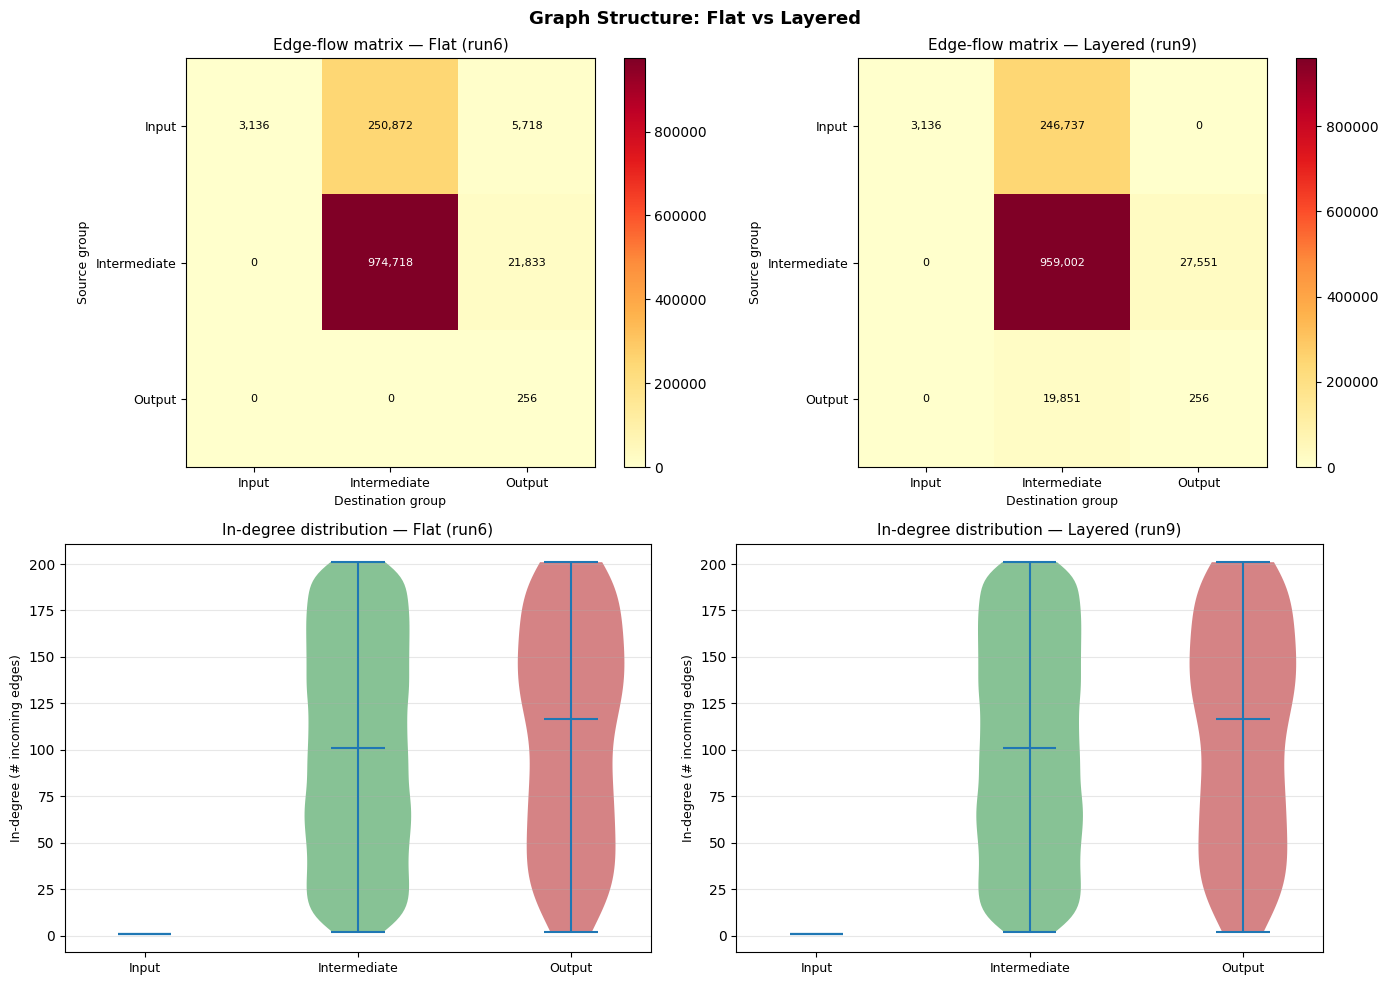

Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run9/analysis_graph_structure.png

── Edge-flow summary ──
  Flat:  input→output=5,718  input→mid=250,872  mid→output=21,833  self-loops=978,110
  Layered:  input→output=0  input→mid=246,737  mid→output=27,551  self-loops=962,394


In [2]:
print("Initialising fresh models (same seed=42, topology differs)...")
m6_fresh, cfg6 = build_model(RUN6_CONFIG)
m9_fresh, cfg9 = build_model(RUN9_CONFIG)
print(f"  run6 topology: {cfg6['graph'].get('topology', 'flat')}")
print(f"  run9 topology: {cfg9['graph'].get('topology', 'layered')}")

# ── Edge-flow matrix ──────────────────────────────────────────────────────
def edge_flow_matrix(gnn):
    """3x3 int matrix: mat[src_group, dst_group] = edge count."""
    ns = gnn._node_store
    ei = ns.edge_indices.cpu()
    src, dst = ei[0], ei[1]
    N = ns.total_nodes
    grp = torch.zeros(N, dtype=torch.long)
    grp[torch.tensor(sorted(ns.intermediate_nodeids), dtype=torch.long)] = 1
    grp[torch.tensor(sorted(ns.output_nodeids),       dtype=torch.long)] = 2
    sg, dg = grp[src], grp[dst]
    mat = torch.zeros(3, 3, dtype=torch.long)
    for i in range(3):
        for j in range(3):
            mat[i, j] = ((sg == i) & (dg == j)).sum()
    return mat.numpy()


# ── In-degree per group ───────────────────────────────────────────────────
def indegree_by_group(gnn):
    ns = gnn._node_store
    ei = ns.edge_indices.cpu()
    N  = ns.total_nodes
    deg = torch.zeros(N, dtype=torch.long)
    deg.scatter_add_(0, ei[1], torch.ones(ei.shape[1], dtype=torch.long))
    return {
        "input":        deg[sorted(ns.input_nodeids)].numpy(),
        "intermediate": deg[sorted(ns.intermediate_nodeids)].numpy(),
        "output":       deg[sorted(ns.output_nodeids)].numpy(),
    }


mat6 = edge_flow_matrix(m6_fresh.gnn)
mat9 = edge_flow_matrix(m9_fresh.gnn)
deg6 = indegree_by_group(m6_fresh.gnn)
deg9 = indegree_by_group(m9_fresh.gnn)

group_labels = ["Input", "Intermediate", "Output"]

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: heatmaps
for ax, mat, title in zip(axes[0], [mat6, mat9], ["Flat (run6)", "Layered (run9)"]):
    im = ax.imshow(mat, cmap="YlOrRd")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_yticklabels(group_labels, fontsize=9)
    ax.set_xlabel("Destination group", fontsize=9)
    ax.set_ylabel("Source group", fontsize=9)
    ax.set_title(f"Edge-flow matrix — {title}", fontsize=11)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{mat[i,j]:,}", ha="center", va="center",
                    fontsize=8, color="white" if mat[i,j] > mat.max()*0.6 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)

# Bottom row: in-degree violin plots
for ax, deg, title in zip(axes[1], [deg6, deg9], ["Flat (run6)", "Layered (run9)"]):
    data = [deg[g] for g in GROUPS]
    parts = ax.violinplot(data, positions=range(3), showmedians=True, showextrema=True)
    for pc, g in zip(parts["bodies"], GROUPS):
        pc.set_facecolor(GROUP_COLORS[g])
        pc.set_alpha(0.7)
    ax.set_xticks(range(3))
    ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_ylabel("In-degree (# incoming edges)", fontsize=9)
    ax.set_title(f"In-degree distribution — {title}", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Graph Structure: Flat vs Layered", fontsize=13, fontweight="bold")
fig.tight_layout()

save_path = RUN_DIR / "run9" / "analysis_graph_structure.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# ── Sanity check ──────────────────────────────────────────────────────────
print("\n── Edge-flow summary ──")
for name, mat in [("Flat", mat6), ("Layered", mat9)]:
    input_to_output = mat[0, 2]
    input_to_mid    = mat[0, 1]
    mid_to_output   = mat[1, 2]
    self_loops      = mat[0,0] + mat[1,1] + mat[2,2]
    print(f"  {name}:  input→output={input_to_output:,}  input→mid={input_to_mid:,}  "
          f"mid→output={mid_to_output:,}  self-loops={self_loops:,}")

---
## Section 2 — Activation Flow (fresh random-init model)

Runs a probe forward pass on a small synthetic batch (no training data needed).  
The `_iter_stats_hook` added to `layer.py` captures mean ± std of `act_strength` per node group at each propagation iteration.

Collected 4 iterations (flat), 6 iterations (layered)


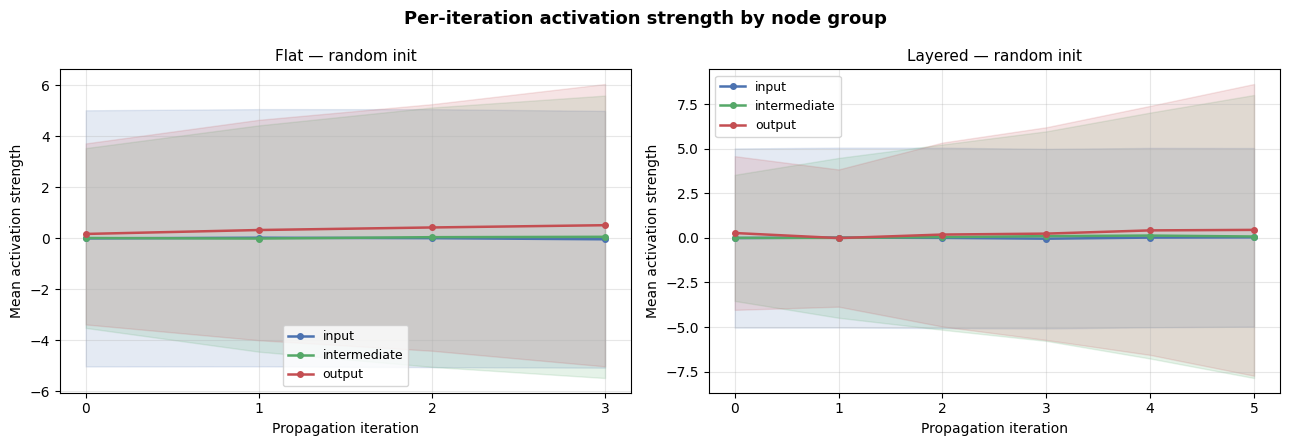

Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run9/analysis_activation_flow_init.png


In [3]:
B = 4
torch.manual_seed(0)
x_synth = torch.randn(B, 512 * 7 * 7, device=DEVICE)

def probe_forward(model, x_batch, in_ids, mid_ids, out_ids):
    stats = attach_iter_collector(model.gnn, in_ids, mid_ids, out_ids)
    model.eval()
    with torch.no_grad():
        _ = model(x_batch)
    detach_hook(model.gnn)
    return stats


in6, mid6, out6 = node_id_groups(m6_fresh.gnn)
in9, mid9, out9 = node_id_groups(m9_fresh.gnn)

stats6_init = probe_forward(m6_fresh, x_synth, in6, mid6, out6)
stats9_init = probe_forward(m9_fresh, x_synth, in9, mid9, out9)
print(f"Collected {len(stats6_init)} iterations (flat), {len(stats9_init)} iterations (layered)")

# ── Plot ──────────────────────────────────────────────────────────────────
def plot_activation_flow(stats_flat, stats_layered, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
    for ax, stats, label in zip(axes, [stats_flat, stats_layered],
                                 [f"Flat — {title_suffix}", f"Layered — {title_suffix}"]):
        iters = [s["iter"] for s in stats]
        for g in GROUPS:
            means = np.array([s[g]["mean"] for s in stats])
            stds  = np.array([s[g]["std"]  for s in stats])
            ax.plot(iters, means, label=g, color=GROUP_COLORS[g], marker="o", markersize=4, linewidth=1.8)
            ax.fill_between(iters, means - stds, means + stds, alpha=0.15, color=GROUP_COLORS[g])
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Propagation iteration")
        ax.set_ylabel("Mean activation strength")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    fig.suptitle("Per-iteration activation strength by node group", fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


fig = plot_activation_flow(stats6_init, stats9_init, title_suffix="random init")
save_path = RUN_DIR / "run9" / "analysis_activation_flow_init.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

---
## Section 3 — Post-training Weight Change

Loads run6 and run9 checkpoints and compares against the fresh random-init models built in Section 1.  
Plots KDE of **(trained − init)** for `phase_weight` and `mag_weight` per node group.  
A group whose delta distribution is tightly centred on 0 did not update its weights during training.

Loading checkpoints...
  run6 loaded
  run9 loaded
Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run6/analysis_weight_distributions.png
Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run9/analysis_weight_distributions.png


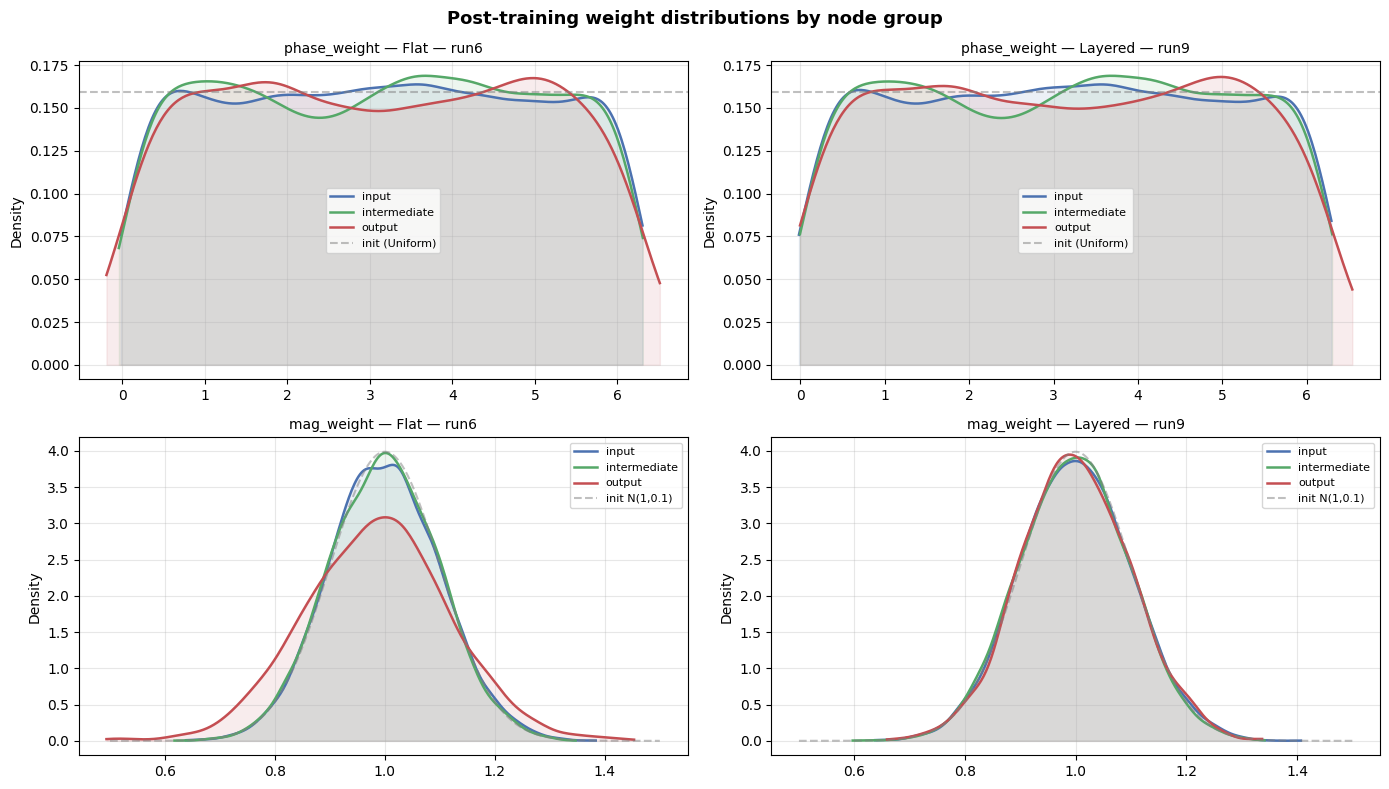

Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run6/analysis_weight_deltas.png
Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run9/analysis_weight_deltas.png


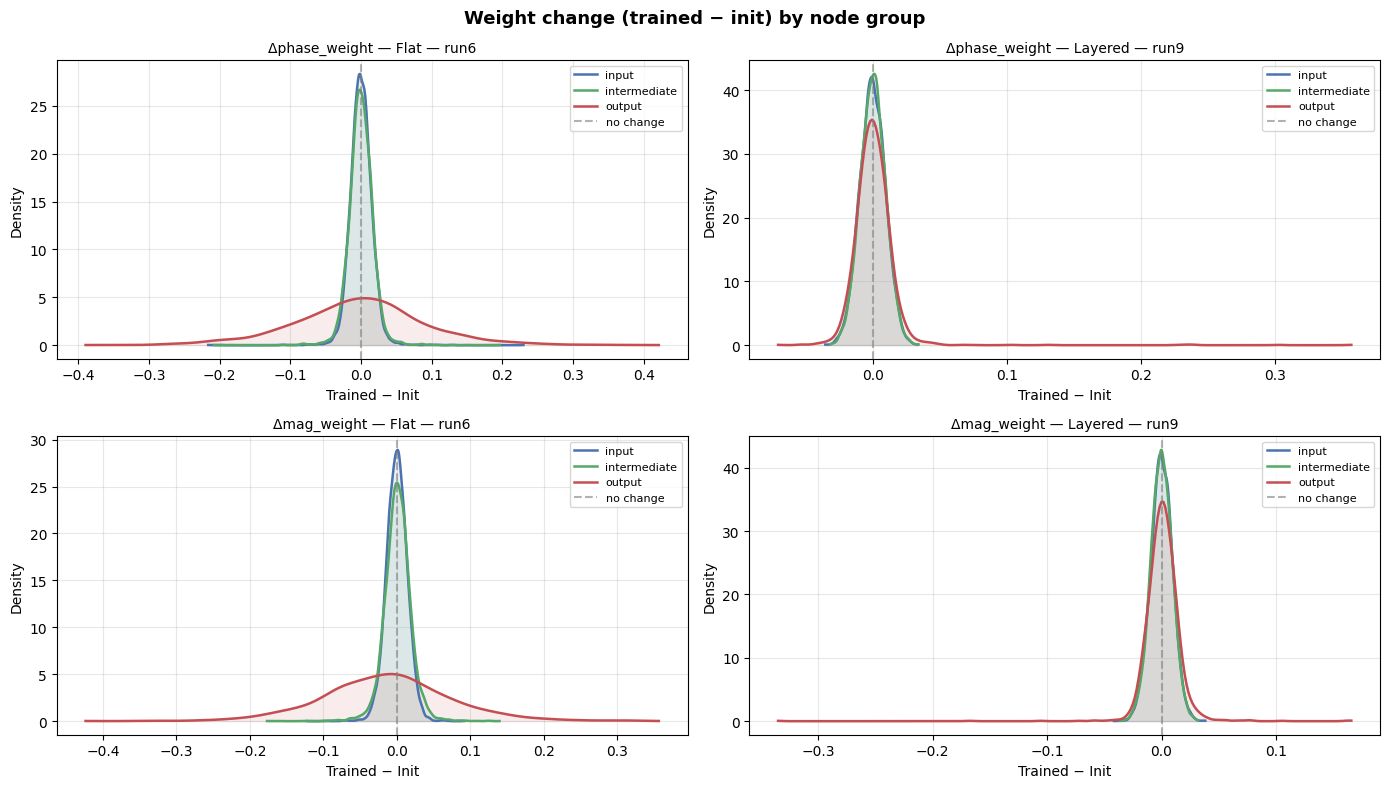

In [4]:
print("Loading checkpoints...")
m6_trained, _ = build_model(RUN6_CONFIG, RUN6_WEIGHTS)
m9_trained, _ = build_model(RUN9_CONFIG, RUN9_WEIGHTS)
print("  run6 loaded")
print("  run9 loaded")

MAX_KDE_SAMPLES = 8_000  # subsample to keep KDE fast

def weight_kdes(gnn, weight_name="phase"):
    """Return {group_name: 1-D numpy array of weight values (subsampled)}."""
    ns   = gnn._node_store
    w    = (ns.phase_weight if weight_name == "phase" else ns.mag_weight).detach().cpu()
    rng  = np.random.default_rng(0)
    result = {}
    for label, ids in [("input",        sorted(ns.input_nodeids)),
                       ("intermediate", sorted(ns.intermediate_nodeids)),
                       ("output",       sorted(ns.output_nodeids))]:
        vals = w[ids].flatten().numpy()
        if len(vals) > MAX_KDE_SAMPLES:
            vals = rng.choice(vals, MAX_KDE_SAMPLES, replace=False)
        result[label] = vals
    return result


def weight_delta(gnn_init, gnn_trained, weight_name="phase"):
    """Return {group_name: 1-D numpy array of (trained − init) weight deltas (subsampled)}."""
    ns_i = gnn_init._node_store
    ns_t = gnn_trained._node_store
    w_i  = (ns_i.phase_weight if weight_name == "phase" else ns_i.mag_weight).detach().cpu()
    w_t  = (ns_t.phase_weight if weight_name == "phase" else ns_t.mag_weight).detach().cpu()
    delta = w_t - w_i
    rng   = np.random.default_rng(0)
    result = {}
    for label, ids in [("input",        sorted(ns_t.input_nodeids)),
                       ("intermediate", sorted(ns_t.intermediate_nodeids)),
                       ("output",       sorted(ns_t.output_nodeids))]:
        vals = delta[ids].flatten().numpy()
        if len(vals) > MAX_KDE_SAMPLES:
            vals = rng.choice(vals, MAX_KDE_SAMPLES, replace=False)
        result[label] = vals
    return result


wt_labels = ["phase_weight", "mag_weight"]
run_items  = [(m6_trained.gnn, "Flat — run6"), (m9_trained.gnn, "Layered — run9")]

# ── Plot 1: absolute distributions ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, wname in enumerate(wt_labels):
    for col, (gnn, run_label) in enumerate(run_items):
        ax  = axes[row][col]
        kdes = weight_kdes(gnn, weight_name=wname.split("_")[0])
        for g in GROUPS:
            vals = kdes[g]
            kde  = gaussian_kde(vals)
            xs   = np.linspace(vals.min(), vals.max(), 300)
            ax.plot(xs, kde(xs), label=g, color=GROUP_COLORS[g], linewidth=1.8)
            ax.fill_between(xs, kde(xs), alpha=0.1, color=GROUP_COLORS[g])

        if wname == "phase_weight":
            xs_ref = np.linspace(0, 2*np.pi, 300)
            ax.axhline(1/(2*np.pi), color="grey", linestyle="--", alpha=0.5, label="init (Uniform)")
        else:
            from scipy.stats import norm as sp_norm
            xs_ref = np.linspace(0.5, 1.5, 300)
            ax.plot(xs_ref, sp_norm.pdf(xs_ref, 1.0, 0.1), color="grey",
                    linestyle="--", alpha=0.5, label="init N(1,0.1)")

        ax.set_title(f"{wname} — {run_label}", fontsize=10)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Post-training weight distributions by node group", fontsize=13, fontweight="bold")
fig.tight_layout()

for run_dir, save_name in [(RUN_DIR/"run6", "analysis_weight_distributions.png"),
                            (RUN_DIR/"run9", "analysis_weight_distributions.png")]:
    p = run_dir / save_name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"Saved: {p}")
plt.show()

# ── Plot 2: weight change (trained − init) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
run_items_delta = [
    (m6_fresh.gnn, m6_trained.gnn, "Flat — run6"),
    (m9_fresh.gnn, m9_trained.gnn, "Layered — run9"),
]

for row, wname in enumerate(wt_labels):
    wkey = wname.split("_")[0]
    for col, (gnn_init, gnn_trained, run_label) in enumerate(run_items_delta):
        ax     = axes[row][col]
        deltas = weight_delta(gnn_init, gnn_trained, weight_name=wkey)
        for g in GROUPS:
            vals = deltas[g]
            kde  = gaussian_kde(vals)
            xs   = np.linspace(vals.min(), vals.max(), 300)
            ax.plot(xs, kde(xs), label=g, color=GROUP_COLORS[g], linewidth=1.8)
            ax.fill_between(xs, kde(xs), alpha=0.1, color=GROUP_COLORS[g])

        ax.axvline(0, color="grey", linestyle="--", alpha=0.6, label="no change")
        ax.set_title(f"Δ{wname} — {run_label}", fontsize=10)
        ax.set_xlabel("Trained − Init")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Weight change (trained − init) by node group", fontsize=13, fontweight="bold")
fig.tight_layout()

for run_dir, save_name in [(RUN_DIR/"run6", "analysis_weight_deltas.png"),
                            (RUN_DIR/"run9", "analysis_weight_deltas.png")]:
    p = run_dir / save_name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"Saved: {p}")
plt.show()

---
## Section 4 — Post-training Activation Flow

Same per-iteration probe as Section 2, but using the **trained checkpoints** and **real validation samples**.  
Shows whether, after training, signal flows differently through flat vs layered.

Loading validation data...
  val batch shape: torch.Size([8, 25088])


Collected 4 iters (flat), 6 iters (layered)
Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run6/analysis_activation_flow_trained.png
Saved: /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run9/analysis_activation_flow_trained.png


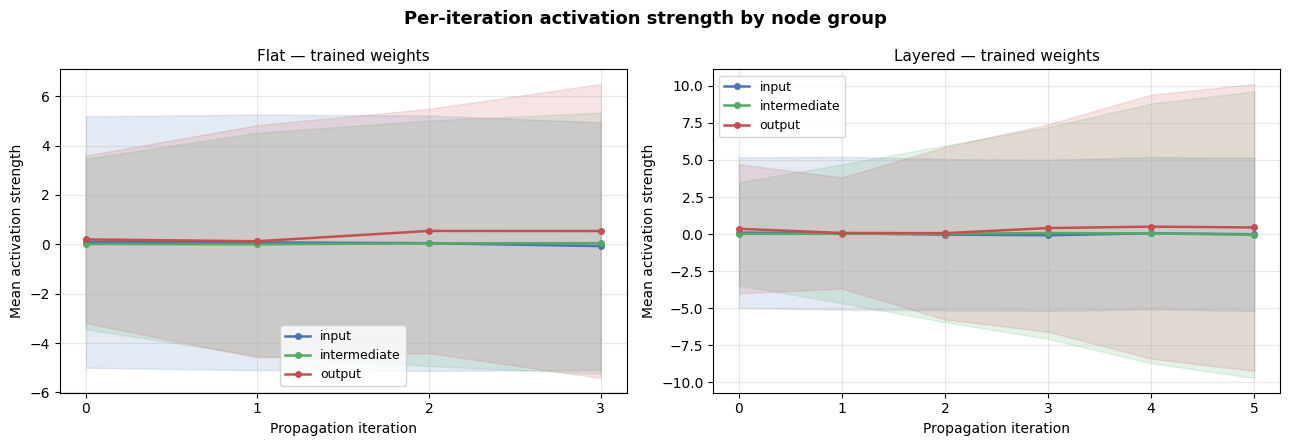

In [5]:
# Load a small slice of real validation data
print("Loading validation data...")
val = torch.load(str(VAL_DATA), map_location="cpu", weights_only=False)
x_val = val["data"][:8]   # 8 samples, shape (8, 25088)
print(f"  val batch shape: {x_val.shape}")

in6t,  mid6t,  out6t  = node_id_groups(m6_trained.gnn)
in9t,  mid9t,  out9t  = node_id_groups(m9_trained.gnn)

stats6_trained = probe_forward(m6_trained, x_val, in6t, mid6t, out6t)
stats9_trained = probe_forward(m9_trained, x_val, in9t, mid9t, out9t)
print(f"Collected {len(stats6_trained)} iters (flat), {len(stats9_trained)} iters (layered)")

fig = plot_activation_flow(stats6_trained, stats9_trained, title_suffix="trained weights")

for run_dir, save_name in [(RUN_DIR/"run6", "analysis_activation_flow_trained.png"),
                            (RUN_DIR/"run9", "analysis_activation_flow_trained.png")]:
    p = run_dir / save_name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"Saved: {p}")
plt.show()

---
## Summary

**What to look for:**

| Plot | Flat (run6) | Layered (run9) — expected if hypothesis holds |
|---|---|---|
| Edge matrix `[Input→Output]` | non-zero | **0** — outputs never get direct input signal |
| Activation flow @ init, output group, iter 1 | starts activating | stays flat until iter 2 |
| Activation flow trained, output group | rising curve | weak / absent rise |
| Weight KDE, output group | shifted from init | nearly same as init |

If the output-group weight KDE in run9 overlaps almost perfectly with the init reference line,
the outputs did not learn — consistent with a gradient-starvation bottleneck.